# Getting Started Examples

This notebook introduces the generic `eigensolver.py` interface through three basic finite-difference examples:

- a one-dimensional harmonic oscillator,
- a two-dimensional harmonic oscillator,
- and a hydrogen atom on a 3D Cartesian grid.

The solver uses the convention

$$\left[-\sum_i k_i\frac{\partial^2}{\partial x_i^2}+\sum_{i<j} c_{ij}\frac{\partial^2}{\partial x_i\partial x_j}+U(x)\right]\psi=E\psi,$$

where the mixed-derivative coefficients $c_{ij}$ are supplied with `k_cross`. These introductory examples use `k_cross=[]`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import eval_hermite, factorial

import pygenstates as eg

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})


def align_phase(reference, candidate, dx):
    """Flip/phase-align a numerical eigenvector before comparing it."""
    overlap = np.sum(np.conjugate(reference) * candidate) * dx
    if np.abs(overlap) == 0:
        return candidate
    return candidate * np.conjugate(overlap) / np.abs(overlap)


## 1D harmonic oscillator

For

$$H=-\frac{d^2}{dx^2}+x^2,$$

the exact eigenvalues are

$$E_n=2n+1,\qquad n=0,1,2,\ldots$$

This is a useful first check because the eigenvalues are simple and the eigenfunctions are Hermite-Gaussian functions.

Numerical eigenvalues: [0.99998594 2.99992969 4.99981718 6.99964842 8.9994234 ]
Exact eigenvalues:     [1 3 5 7 9]
Errors:                [-1.40626989e-05 -7.03142804e-05 -1.82819414e-04 -3.51580336e-04
 -5.76597317e-04]


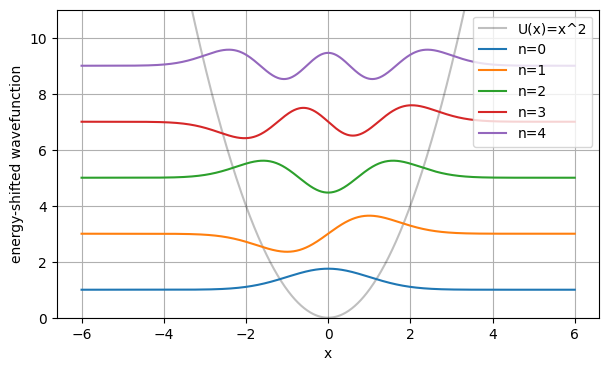

In [2]:
def harmonic_1d_state(n, x):
    norm = 1.0 / np.sqrt((2.0 ** n) * factorial(n) * np.sqrt(np.pi))
    return norm * eval_hermite(n, x) * np.exp(-0.5 * x**2)


U_ho_1d = lambda x: x**2

vals, vecs, xlists = eg.eigensolver(
    U_ho_1d,
    N=[801],
    domain=[(-6, 6)],
    k_diag=[1],
    Enum=5,
    which="SA",
)

x = xlists[0]
exact_vals = np.array([2*n + 1 for n in range(5)])

print("Numerical eigenvalues:", vals)
print("Exact eigenvalues:    ", exact_vals)
print("Errors:               ", vals - exact_vals)

plt.plot(x, U_ho_1d(x), "k", alpha=0.25, label="U(x)=x^2")
for n in range(5):
    psi_exact = harmonic_1d_state(n, x)
    psi_num = align_phase(psi_exact, vecs[n], x[1] - x[0])
    plt.plot(x, psi_num + vals[n], label=f"n={n}")
plt.ylim(0, 11)
plt.xlabel("x")
plt.ylabel("energy-shifted wavefunction")
plt.legend()
plt.show()


## 2D harmonic oscillator

For

$$H=-\frac{\partial^2}{\partial x^2}-\frac{\partial^2}{\partial y^2}+x^2+y^2,$$

the separability of the Hamiltonian gives

$$E_{n_x,n_y}=(2n_x+1)+(2n_y+1).$$

The first state has energy $2$, and the first excited pair is degenerate at energy $4$.

Numerical eigenvalues: [1.9992017  3.99762905 3.99762905 5.99479923 5.99479923 5.99605641]
Exact eigenvalues:     [2 4 4 6 6 6]
Errors:                [-0.0007983  -0.00237095 -0.00237095 -0.00520077 -0.00520077 -0.00394359]


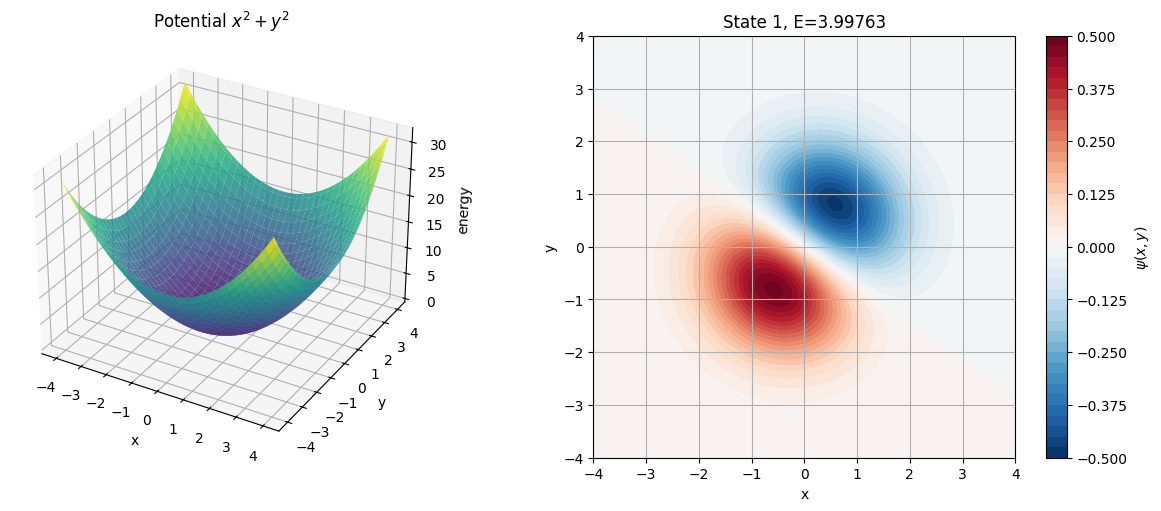

In [3]:
U_ho_2d = lambda x, y: x**2 + y**2

vals, vecs, xlists = eg.eigensolver(
    U_ho_2d,
    N=[101, 101],
    domain=[(-4, 4), (-4, 4)],
    k_diag=[1, 1],
    Enum=6,
    which="SA",
)

exact_2d = sorted([(2*nx + 1) + (2*ny + 1) for nx in range(4) for ny in range(4)])[:6]
print("Numerical eigenvalues:", vals)
print("Exact eigenvalues:    ", np.array(exact_2d))
print("Errors:               ", vals - np.array(exact_2d))

x, y = xlists
X, Y = np.meshgrid(x, y, indexing="ij")

state_to_plot = 1

fig = plt.figure(figsize=(12, 5), constrained_layout=True)

ax0 = fig.add_subplot(121, projection="3d")
ax0.plot_surface(X, Y, U_ho_2d(X, Y), cmap="viridis", alpha=0.85)
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_zlabel("energy")
ax0.set_title("Potential $x^2+y^2$")

ax1 = fig.add_subplot(122)
psi_plot = np.real(vecs[state_to_plot])
im = ax1.contourf(X, Y, psi_plot, levels=40, cmap="RdBu_r")
ax1.set_aspect("equal")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title(f"State {state_to_plot}, E={vals[state_to_plot]:.5f}")
fig.colorbar(im, ax=ax1, label="$\\psi(x,y)$")
plt.show()


## Hydrogen atom on a Cartesian grid: finite difference

In SI-derived units, using coordinates in angstroms and energies in eV,

$$H=-\frac{\hbar^2}{2m_e}\nabla^2-\frac{e^2}{4\pi\epsilon_0 r}.$$

The singularity at $r=0$ is clipped at a small radius, and the potential is shifted upward by a constant. After solving, that offset is subtracted again. This is a direct Cartesian-grid example rather than a specialized radial hydrogen solver, so convergence improves by increasing `N_size`, increasing `dom`, and carefully reducing the cutoff.

Numerical bound energies, eV: [-16.05865917  -4.00341764  -3.48067801  -3.48067801  -3.48067801]
Reference pattern, eV:        [-13.6  -3.4  -3.4  -3.4  -3.4]
Errors, eV:                   [-2.45865917 -0.60341764 -0.08067801 -0.08067801 -0.08067801]


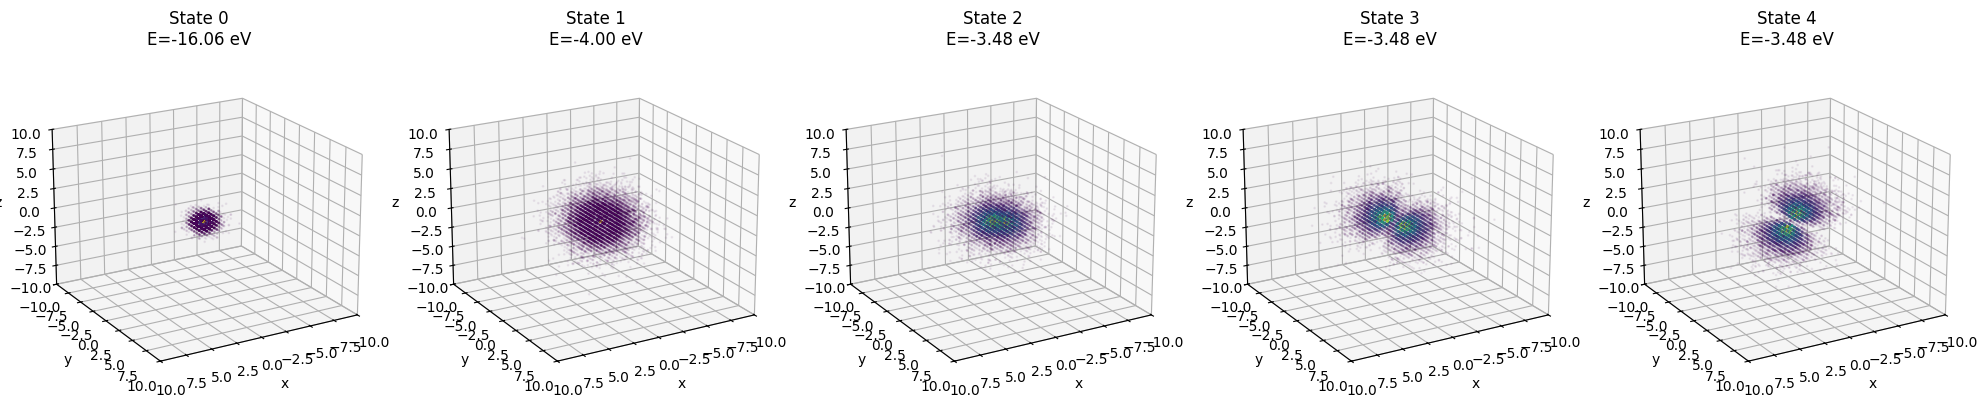

In [4]:
q_e = 1.60217663e-19
m_e = 9.1093837e-31
eps0 = 8.85418782e-12
hbar = 1.054571817e-34

r_cutoff = 0.2  # Angstrom; smaller is more physical but requires a finer grid
k_HA_2eV = hbar**2 / (2 * m_e * q_e * 1e-20)
offset = q_e * 1e10 / (r_cutoff * eps0 * 4 * np.pi)


def U_hydrogen_shifted(x, y, z):
    r = np.sqrt(x*x + y*y + z*z)
    r_eff = np.maximum(r, r_cutoff)
    return -q_e * 1e10 / (r_eff * eps0 * 4 * np.pi) + offset


def U_hydrogen_radial_shifted(r):
    r_eff = np.maximum(r, r_cutoff)
    return -q_e * 1e10 / (r_eff * eps0 * 4 * np.pi) + offset


N_size = 41
dom = 10
Enum = 5

vals, vecs, xlists = eg.eigensolver(
    U_hydrogen_shifted,
    N=[N_size, N_size, N_size],
    domain=[(-dom, dom), (-dom, dom), (-dom, dom)],
    k_diag=[k_HA_2eV, k_HA_2eV, k_HA_2eV],
    Enum=Enum,
    method="finite_difference",
    which="SA",
)

hydrogen_vals = vals - offset
expected = np.array([-13.6 / n**2 for n in [1, 2, 2, 2, 2]])

print("Numerical bound energies, eV:", hydrogen_vals)
print("Reference pattern, eV:       ", expected)
print("Errors, eV:                  ", hydrogen_vals - expected)

num_points = 12000
rng = np.random.default_rng(1234)

fig = plt.figure(figsize=(4 * Enum, 4))

for state in range(Enum):
    rho = np.abs(vecs[state])**2
    rho_flat = rho.ravel()
    rho_flat = rho_flat / rho_flat.sum()

    sample = rng.choice(len(rho_flat), size=num_points, p=rho_flat)

    Nx, Ny, Nz = rho.shape
    i = sample // (Ny * Nz)
    j = (sample % (Ny * Nz)) // Nz
    k = sample % Nz

    x = xlists[0][i]
    y = xlists[1][j]
    z = xlists[2][k]
    colour = rho[i, j, k]

    ax = fig.add_subplot(1, Enum, state + 1, projection="3d")
    ax.view_init(elev=20, azim=60)
    ax.scatter(x, y, z, c=colour, s=1, alpha=0.06, cmap="viridis")
    ax.set_xlim(-dom, dom)
    ax.set_ylim(-dom, dom)
    ax.set_zlim(-dom, dom)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"State {state}\nE={hydrogen_vals[state]:.2f} eV")

plt.tight_layout()
plt.show()
